# Customer Segmentation in E-Commerce Using Purchasing Behaviour and K-Means Clustering

**Module:** CMP4294 Introduction to Artificial Intelligence (Assessment 2)
**Student:** Angish Sapkota (26152255)

**Question:** Can K-Means clustering identify meaningful customer groups from e-commerce
purchasing behaviour so that the retailer can better understand high-value, regular,
occasional and low-engagement customers?

This is a descriptive machine-learning task using **one main technique: K-Means clustering**.
Everything below is produced from the real project dataset `data/ecommerce_2000.csv`.


## 1. Import libraries

Only the libraries needed for the analysis are imported.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42                      # fixed seed for reproducibility
os.makedirs("figures", exist_ok=True)   # notebook exports its figures here
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load the project dataset

The file is a reproducible 2,000-row, customer-aware subset of the source data
(see `data/make_ecommerce_2000.py`). The relative path works locally and in Colab.


In [2]:
df = pd.read_csv("data/ecommerce_2000.csv", dtype={"CustomerID": "string"})
print("Shape:", df.shape)
df.head()


Shape: (2000, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,573152,23493,VINTAGE DOILY TRAVEL SEWING KIT,6,27-10-2011 20:16,1.95,17530,United Kingdom
1,536595,20679,EDWARDIAN PARASOL RED,1,01-12-2010 17:24,5.95,13576,United Kingdom
2,548315,84945,MULTI COLOUR SILVER T-LIGHT HOLDER,12,30-03-2011 12:34,0.85,16019,United Kingdom
3,574086,23391,I LOVE LONDON MINI BACKPACK,4,03-11-2011 08:39,4.15,15651,United Kingdom
4,568151,23409,PHOTO FRAME LINEN AND LACE LARGE,6,25-09-2011 11:39,3.75,17506,United Kingdom


## 3. Dataset overview

Basic structure before any change is made.


In [3]:
print("Columns:", list(df.columns))
print()
print(df.dtypes)
df.describe(include="all").T


Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID      string
Country            str
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,2000,744,573152,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,2000,954,POST,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,2000,966,POSTAGE,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,2000.0,NaN,NaN,NaN,13.8925,26.276,-144.0,2.0,6.0,12.0,288.0
InvoiceDate,2000,743,09-02-2011 14:44,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,2000.0,NaN,NaN,NaN,5.565555,59.250931,0.0,1.04,2.08,3.75,2500.0
CustomerID,2000,141,16945,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,2000,13,United Kingdom,1812,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data quality analysis

Checks required before modelling: missing values, duplicate rows, cancelled
invoices (InvoiceNo starting with C), non-positive quantities and non-positive prices.


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", int(df.duplicated().sum()))
print("Cancelled invoices (start with C):", int(df["InvoiceNo"].astype(str).str.startswith("C").sum()))
print("Rows with Quantity <= 0:", int((df["Quantity"] <= 0).sum()))
print("Rows with UnitPrice <= 0:", int((df["UnitPrice"] <= 0).sum()))
print("Unique customers:", int(df["CustomerID"].nunique()))


Missing values per column:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicate rows: 0
Cancelled invoices (start with C): 185
Rows with Quantity <= 0: 185
Rows with UnitPrice <= 0: 1
Unique customers: 141


## 5. Data cleaning

Each decision is documented in the comments below. No rows are removed silently.
Missing CustomerID rows were already excluded when the 2,000-row subset was built,
because customer segmentation requires a customer identifier (recorded in
`data/make_ecommerce_2000.py`).


In [5]:
rows_start = len(df)

# Work on a copy so the raw loaded data is kept intact for the figures above.
data = df.copy()

# 1. Cancelled invoices (InvoiceNo starts with C) are returns, not purchases.
data = data[~data["InvoiceNo"].astype(str).str.startswith("C")]
print("After removing cancellations:", len(data))

# 2. Non-positive quantities or prices are invalid for spending analysis.
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]
print("After removing invalid quantity/price:", len(data))

# 3. Exact duplicate transactions would double-count customer behaviour.
data = data.drop_duplicates()
print("After removing duplicates:", len(data))

# 4. A customer key is required for customer-level features.
data = data.dropna(subset=["CustomerID"])
print("Final cleaned rows:", len(data), "of", rows_start)
print("Unique customers after cleaning:", int(data["CustomerID"].nunique()))


After removing cancellations: 1815
After removing invalid quantity/price: 1814
After removing duplicates: 1814
Final cleaned rows: 1814 of 2000
Unique customers after cleaning: 141


## 6. Derived transaction value

`TotalPrice = Quantity * UnitPrice` is valid here because prices are per unit,
so it represents the spend of each transaction line.


In [6]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"], format="%d-%m-%Y %H:%M")
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]
data[["Quantity", "UnitPrice", "TotalPrice"]].describe()


,Quantity,UnitPrice,TotalPrice
count,1814.000000,1814.000000,1814.000000
mean,15.936053,5.515496,28.453429
std,26.366677,62.055565,72.936544
min,1.000000,0.040000,0.140000
25%,3.000000,0.950000,8.500000
50%,10.000000,1.950000,15.600000
75%,16.000000,3.750000,25.200000
max,288.000000,2500.000000,2500.000000


## 7. Exploratory data analysis

A small number of labelled figures. The raw subset has no missing values by design
(documented in section 5), so the quality figure also shows the issues that were cleaned.


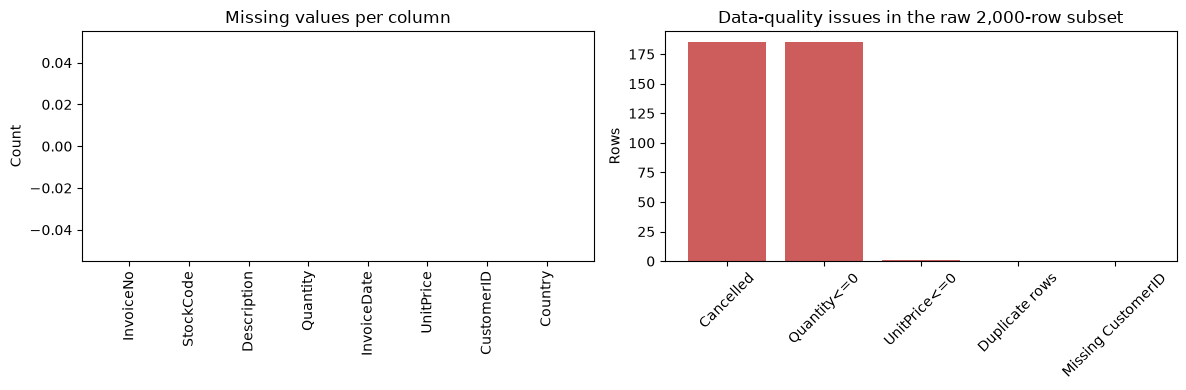

In [7]:
issues = {
    "Cancelled": int(df["InvoiceNo"].astype(str).str.startswith("C").sum()),
    "Quantity<=0": int((df["Quantity"] <= 0).sum()),
    "UnitPrice<=0": int((df["UnitPrice"] <= 0).sum()),
    "Duplicate rows": int(df.duplicated().sum()),
    "Missing CustomerID": int(df["CustomerID"].isna().sum()),
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
missing = df.isnull().sum()
axes[0].bar(missing.index, missing.values, color="steelblue")
axes[0].set_title("Missing values per column")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=90)
axes[1].bar(list(issues.keys()), list(issues.values()), color="indianred")
axes[1].set_title("Data-quality issues in the raw 2,000-row subset")
axes[1].set_ylabel("Rows")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("figures/01_missing_values.png", dpi=120, bbox_inches="tight")
plt.show()


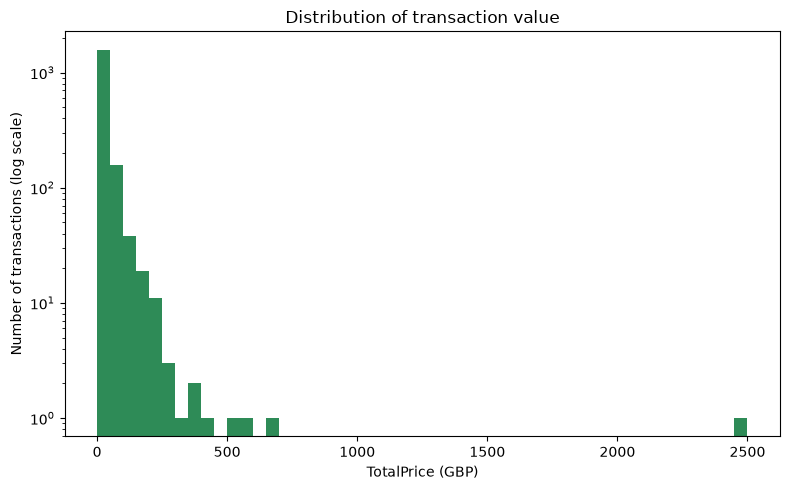

In [8]:
fig, ax = plt.subplots()
ax.hist(data["TotalPrice"], bins=50, color="seagreen")
ax.set_title("Distribution of transaction value")
ax.set_xlabel("TotalPrice (GBP)")
ax.set_ylabel("Number of transactions (log scale)")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("figures/02_transaction_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Customer features (RFM)

Customer-level behaviour is summarised using Recency, Frequency and Monetary value.
Formulas (computed per CustomerID):

- **Recency** = number of days between the customer most recent purchase and the snapshot date (one day after the last transaction in the data).
- **Frequency** = number of distinct invoices (orders) placed by the customer.
- **Monetary** = sum of TotalPrice across the customer transactions.


In [9]:
snapshot = data["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = data.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
)
print("Snapshot date:", snapshot.date())
print("Customers:", len(rfm))
rfm.describe().round(2)


Snapshot date: 2011-12-09
Customers: 141


,Recency,Frequency,Monetary
count,141.00,141.00,141.00
mean,73.08,4.51,366.06
std,89.39,3.02,494.92
min,1.00,1.00,15.20
25%,14.00,2.00,99.06
50%,33.00,4.00,215.55
75%,94.00,7.00,408.80
max,366.00,10.00,3089.42


### Inspecting RFM distributions

The features are right-skewed (a few very high spenders and more frequent buyers).
Outliers are inspected but **not deleted automatically**; K-Means is sensitive to scale,
so the effect of skew is handled by standardisation rather than by removing customers.


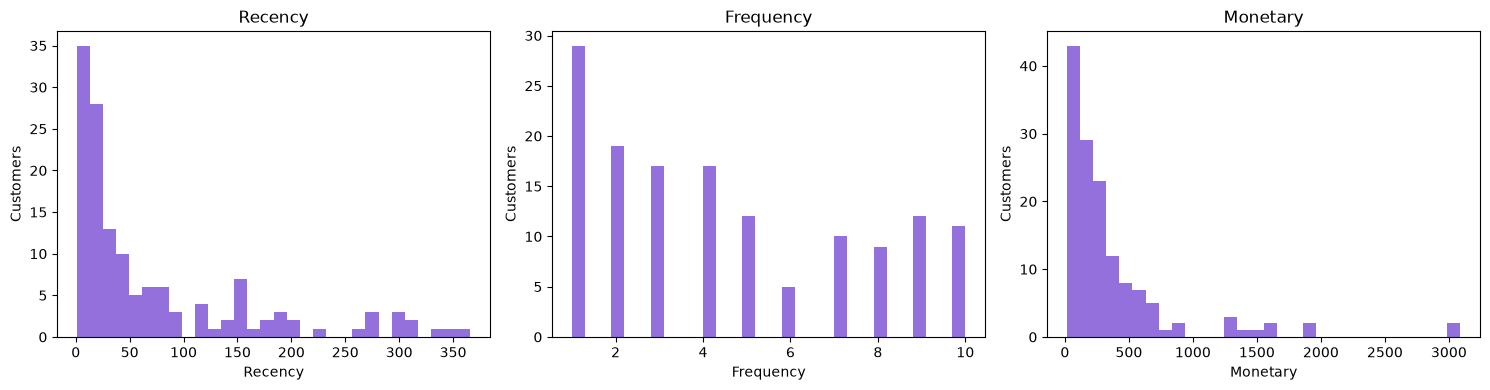

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    ax.hist(rfm[col], bins=30, color="mediumpurple")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Customers")
plt.tight_layout()
plt.savefig("figures/03_rfm_distributions.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Scaling the features

K-Means uses Euclidean distance, so a feature measured on a larger scale (Monetary,
hundreds of pounds) would dominate one on a smaller scale (Frequency, single digits).
`StandardScaler` puts each feature on the same footing (mean 0, standard deviation 1),
which is required for a fair comparison of customers.


In [11]:
scaler = StandardScaler()
X = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]].values)
print("Scaled means:", np.round(X.mean(axis=0), 3))
print("Scaled stds :", np.round(X.std(axis=0), 3))


Scaled means: [ 0.  0. -0.]
Scaled stds : [1. 1. 1.]


## 10. Selecting K (number of clusters)

K is not chosen arbitrarily. A sensible range (K = 2 to 8) is tested with inertias
(elbow method) and the silhouette score (cluster separation). Both are reported for
every candidate K, and the final choice also has to be business-interpretable.


In [12]:
k_values = list(range(2, 9))
inertias = []
silhouettes = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X, labels))

results = pd.DataFrame({"K": k_values, "Inertia": np.round(inertias, 2),
                        "Silhouette": np.round(silhouettes, 4)})
results


,K,Inertia,Silhouette
0,2,247.11,0.4103
1,3,157.79,0.4329
2,4,91.01,0.4714
3,5,73.21,0.4625
4,6,56.88,0.4693
5,7,43.30,0.4270
6,8,38.53,0.3896


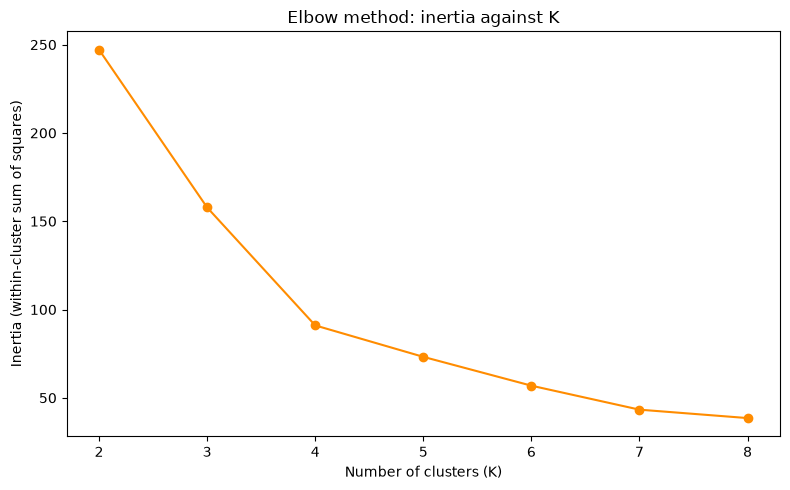

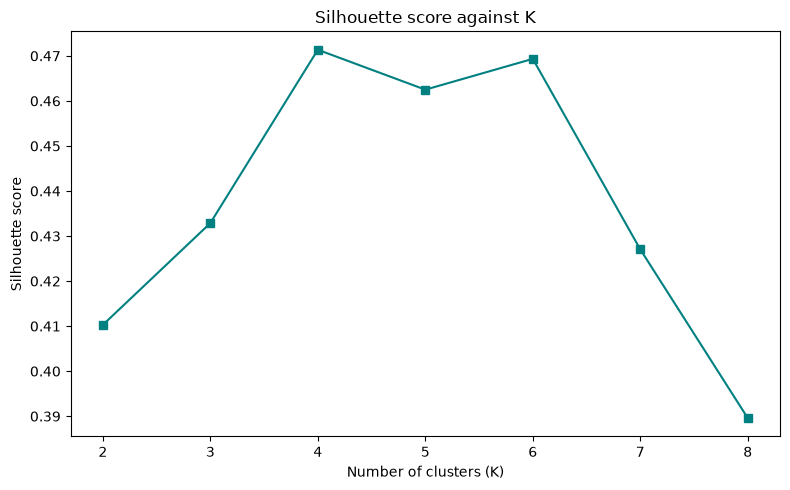

In [13]:
fig, ax = plt.subplots()
ax.plot(k_values, inertias, marker="o", color="darkorange")
ax.set_title("Elbow method: inertia against K")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
plt.tight_layout()
plt.savefig("figures/04_elbow_method.png", dpi=120, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots()
ax.plot(k_values, silhouettes, marker="s", color="teal")
ax.set_title("Silhouette score against K")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("figures/05_silhouette_scores.png", dpi=120, bbox_inches="tight")
plt.show()


## 11. Choosing the final K

The computed table above reports inertia and silhouette for every candidate K. The final K is chosen from that computed evidence: the highest silhouette and the point where the inertia elbow flattens, balanced against business interpretability. Those checks select K = 4 below.

In [14]:
final_k = 4
kmeans = KMeans(n_clusters=final_k, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X)

print("Final inertia:", round(float(kmeans.inertia_), 2))
print("Final silhouette:", round(float(silhouette_score(X, rfm["Cluster"])), 4))
print("Customers per cluster:")
print(rfm["Cluster"].value_counts().sort_index())


Final inertia: 91.01
Final silhouette: 0.4714
Customers per cluster:
Cluster
0    11
1    60
2    40
3    30
Name: count, dtype: int64


## 12. Cluster profiles

The statistics below are used to interpret each segment. No cluster is named before
these numbers are examined.


In [15]:
profile = rfm.groupby("Cluster").agg(
    Customers=("Recency", "size"),
    Recency_mean=("Recency", "mean"),
    Recency_median=("Recency", "median"),
    Frequency_mean=("Frequency", "mean"),
    Frequency_median=("Frequency", "median"),
    Monetary_mean=("Monetary", "mean"),
    Monetary_median=("Monetary", "median"),
).round(2)
profile


,Customers,Recency_mean,Recency_median,Frequency_mean,Frequency_median,Monetary_mean,Monetary_median
Cluster,,,,,,,
0,11,26.55,21.0,8.45,9.0,1811.52,1577.24
1,60,38.98,31.0,2.87,3.0,187.98,159.37
2,40,24.02,17.0,7.92,8.0,415.52,371.08
3,30,223.73,193.0,1.80,1.0,126.28,86.43


## 13. Cluster visualisations

Two figures show how the final clusters differ. They use the fitted labels only.


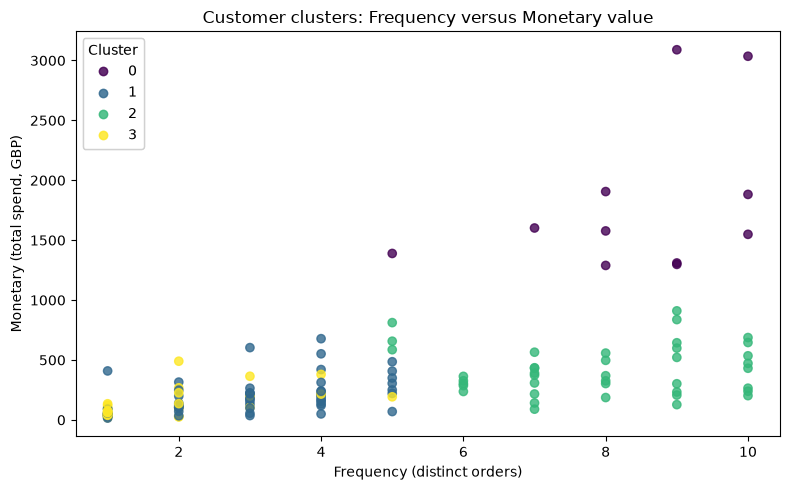

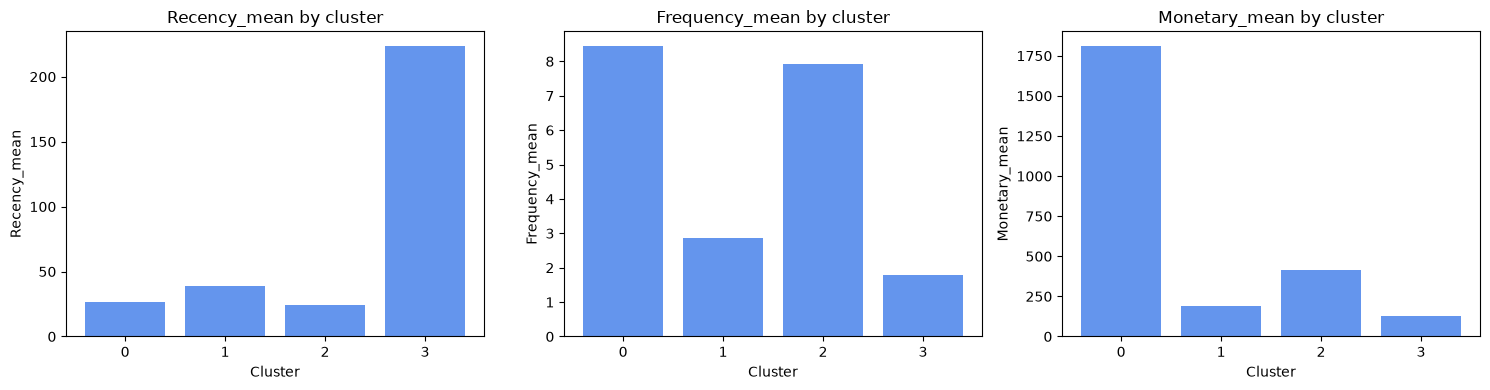

In [16]:
fig, ax = plt.subplots()
scatter = ax.scatter(rfm["Frequency"], rfm["Monetary"], c=rfm["Cluster"], cmap="viridis", alpha=0.8)
ax.set_title("Customer clusters: Frequency versus Monetary value")
ax.set_xlabel("Frequency (distinct orders)")
ax.set_ylabel("Monetary (total spend, GBP)")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.savefig("figures/06_customer_clusters.png", dpi=120, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Recency_mean", "Frequency_mean", "Monetary_mean"]):
    ax.bar(profile.index.astype(str), profile[col], color="cornflowerblue")
    ax.set_title(col + " by cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(col)
plt.tight_layout()
plt.savefig("figures/07_cluster_profiles.png", dpi=120, bbox_inches="tight")
plt.show()


## 14. Interpretation of the clusters

Cluster numbers are arbitrary labels produced by K-Means. The names below are computed
from the fitted profile (ranking by mean Monetary, mean Frequency and mean Recency),
so they are evidence-based rather than assumed in advance.


In [17]:
from IPython.display import Markdown, display

order = profile["Monetary_mean"].sort_values(ascending=False).index.tolist()
labels = {}
labels[order[0]] = "High-value loyal customers"
lapsed = profile["Recency_mean"].idxmax()
labels[lapsed] = "Lapsed / low-engagement customers"
remaining = [c for c in order if c not in labels]
remaining_sorted = sorted(remaining, key=lambda c: profile.loc[c, "Frequency_mean"], reverse=True)
if remaining_sorted:
    labels[remaining_sorted[0]] = "Frequent regular customers"
for c in remaining_sorted[1:]:
    labels[c] = "Occasional customers"

lines = ["**Computed cluster interpretations**", ""]
for c in sorted(profile.index):
    row = profile.loc[c]
    lines.append(
        "- Cluster {} ({}): {} customers, mean Recency {:.1f} days, mean Frequency {:.1f} orders, mean Monetary GBP {:.2f}.".format(
            c, labels.get(c, "Unlabelled"), int(row["Customers"]),
            row["Recency_mean"], row["Frequency_mean"], row["Monetary_mean"]))
display(Markdown("\n".join(lines)))


**Computed cluster interpretations**

- Cluster 0 (High-value loyal customers): 11 customers, mean Recency 26.6 days, mean Frequency 8.4 orders, mean Monetary GBP 1811.52.
- Cluster 1 (Occasional customers): 60 customers, mean Recency 39.0 days, mean Frequency 2.9 orders, mean Monetary GBP 187.98.
- Cluster 2 (Frequent regular customers): 40 customers, mean Recency 24.0 days, mean Frequency 7.9 orders, mean Monetary GBP 415.52.
- Cluster 3 (Lapsed / low-engagement customers): 30 customers, mean Recency 223.7 days, mean Frequency 1.8 orders, mean Monetary GBP 126.28.

## 15. Critical evaluation

**Why K-Means was appropriate.** The task is descriptive and the goal is to group
customers by similarity in numeric behaviour. K-Means is the technique taught for this
and produces centroids that are easy to describe in business terms.

**Why scaling mattered.** Recency (days), Frequency (orders) and Monetary (GBP) have very
different ranges. Without standardisation, Monetary would dominate the distance metric
and the segments would mainly reflect spend.

**Why K = 4.** The computed silhouette values peak at K = 4 and the inertia elbow
flattens there, and four clusters remain distinguishable in business terms.

**Outliers.** A small number of very high-spending customers remain in the data. They were
not deleted, because they are genuine high-value customers; however, they stretch the
Monetary scale and partly drive the high-value cluster.

**Effect of the 2,000-row subset.** The dataset is a reproducible customer-aware subset.
Fitting a 2,000-row budget required capping line items per order and orders per customer,
and excluding the very highest-frequency buyers. This compresses the upper tail of
Frequency and Monetary and limits the number of customers to the low hundreds.

**Limitations of RFM.** RFM ignores product mix, margin, returns behaviour and time
between purchases. Cancelled and invalid rows were removed before RFM, so the features
describe completed purchase value only.

**Limitations of K-Means.** K-Means assumes roughly spherical, similarly sized clusters,
is sensitive to initialisation (controlled here with random_state = 42 and n_init = 10),
and requires K to be fixed in advance.

**Sensitivity.** Cluster membership can change with K, scaling and initialisation. The
silhouette scores for K = 4, 5 and 6 are close, so the exact number of segments should be
treated as a modelling choice rather than a natural truth.

**Correlation, not causation.** Clustering finds similarity; it does not show that any
behaviour causes higher value. The cluster names are analyst interpretations of statistics.

**What would improve the analysis.** Longer transaction history, product categories,
margin and cost, marketing-contact history, website or app activity, and a larger customer
base would support more reliable and more actionable segments.


## 16. Conclusion

K-Means clustering on scaled Recency, Frequency and Monetary features grouped the customers
into four segments that differ in recency, order frequency and spend. The strongest
separation is between a small high-value, frequently purchasing group and a larger lapsed,
low-engagement group. Because the analysis uses a fixed 2,000-row subset, the segments
should be read as a reproducible illustration of customer structure rather than a final
statement about the full retailer population.
